In [6]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
import galacticus_sed_calculator.sed_calculator as sed
import synphot
from synphot import units
import h5py

#### Calculating observed spectra from Galacticus star formation histories

First we generate an `SEDCalculator`, this needs to know the cosmology we want to adopt (to calculate luminosity distances from redshifts), as well as the location of a file generated by Galacticus that contains the mapping between a unit of star formation at a particular age and metallicity and the resulting SED. Galacticus here was run on the [UNIT](http://www.unitsims.org) simulations, so we adopt the same cosmology.

In [8]:
unit = FlatLambdaCDM(H0=67.74, Om0=0.3089)
sedTemplateFilename="../data/nodePropertyExtractorSED_Nt50_NZ11_ageMinimum0.001.hdf5"
sedCalc = sed.SEDCalculator(sedTemplateFilename, cosmology=unit)

The SED template files generated by Galacticus depend on a number of Galacticus parameters that control the binning (both in age and metallicity) of the star formation history. Below we build an alternative SED calculator from a Galacticus run that used a different SFH binning scheme. The `SEDCalculator` should raise an error if one uses incompatible SED templates and saved SFHs (shown later).

In [9]:
sedTemplateFilename="../data/nodePropertyExtractorSED_Nt50_NZ11_ageMinimum0.003.hdf5"
sedCalcAlternative = sed.SEDCalculator(sedTemplateFilename, cosmology=unit)

If we want to use this calculator to generate spectra for a particular galaxy then we need to specify the filename (of a Galactcicus hdf5 file) and the index of the galaxy within that file. 

In [13]:
galIndex = 0
fname = "../data/romanUNIT.hdf5" # galacticus output file

We also should specify the observed wavelength range over which we would like to evaluate the spectrum. Note that our final spectrum will not necessarily use this exact wavelength array, because [`synphot`](https://synphot.readthedocs.io/en/stable/index.html#) is used to add in the emission lines, and this uses an adaptive resolution to capture narrow emission lines.

In [14]:
obs_wavelengths = np.linspace(0.4, 2.5, 1000)*u.micron

Let's start by evaluating the spectrum due to the disk of `galIndex = 0`

In [15]:
disk_flux = sedCalc.evaluate_component_spectrum(fname, galIndex, component='disk', obs_wavelengths=obs_wavelengths)

And let's check what happens if we use an SED calculator with SFH binning that is different from what was used by Galacticus to generate our galaxy catalogue.

In [16]:
sedCalcAlternative.evaluate_component_spectrum(fname, galIndex, component='disk', obs_wavelengths=obs_wavelengths)

ValueError: SED template and star formation history are incompatible:
  ageMinimum mismatch: SFH=0.001, SED template=0.0030000000000004468

The above should fail due to trying to use a Galacticus catalogue and SED template file that relied on different age and/or metallicity binning.

`disk_flux` is a `synphot` `SourceSpectrum` object, so has various useful methods. For example, you can easily plot it:

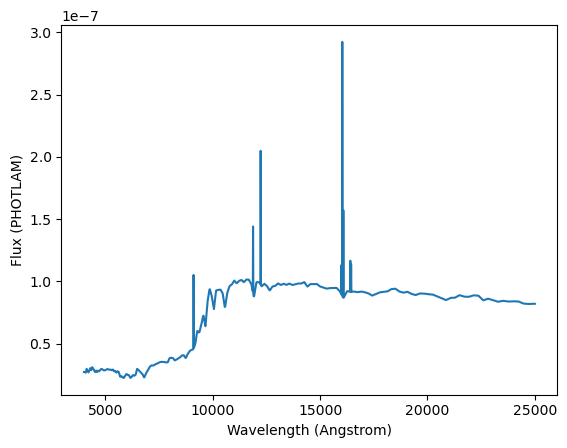

In [17]:
disk_flux.plot()

For the grism simulations we probably just need the wavelengths and associated fluxes, which can be accessed as follows

In [18]:
print(disk_flux.waveset)

[ 4000.          4021.02102102  4042.04204204 ... 24957.95795796
 24978.97897898 25000.        ] Angstrom


In [19]:
print(disk_flux(disk_flux.waveset))

[2.71877573e-08 2.71189562e-08 2.71000651e-08 ... 8.19817045e-08
 8.19817600e-08 8.19312873e-08] PHOTLAM


Note that these are both arrays of astropy quantities, so they can be expressed in other (suitable) units.

In [20]:
print(disk_flux.waveset.to(u.micron))

[0.4       0.4021021 0.4042042 ... 2.4957958 2.4978979 2.5      ] micron


And the flux can be expressed per unit wavelength or frequency, and can be used with astropy unit functionality.

In [21]:
print(disk_flux(disk_flux.waveset, flux_unit='FNU'))
print(disk_flux(disk_flux.waveset, flux_unit='FLAM'))
u.fnu = u.erg/u.s/u.cm**2/u.Hz # see e.g. https://synphot.readthedocs.io/en/stable/synphot/units.html
print(disk_flux(disk_flux.waveset, flux_unit='FNU').to_value(u.fnu))

[7.20591949e-31 7.22545737e-31 7.25817091e-31 ... 1.35575752e-29
 1.35690033e-29 1.35720614e-29] FNU
[1.35017520e-19 1.33971790e-19 1.33182217e-19 ... 6.52506177e-20
 6.51957503e-20 6.51008265e-20] FLAM
[7.20591949e-31 7.22545737e-31 7.25817091e-31 ... 1.35575752e-29
 1.35690033e-29 1.35720614e-29]


#### Wavelength arrays

The `synphot` `SourceSpectrum` object that is returned has a non-uniform wavelength resolution. This is because we first generate a `SourceSpectrum` object for the continuum flux, and then add to it `SourceSpectrum` objects for each emission line. The wavelength-range and wavelength-resolution of each emission line spectrum is determined by `synphot` to properly cover and resolve the line. The result of adding these together is a spectrum on a non-uniform wavelength grid, with higher resolution around the emission lines. Maybe this is OK (or even desirable) in terms of putting this spectrum into `grizli`, but I thought I should point this out in case we want/need to ensure a uniform wavelength grid before passing this to `grizli`.

Text(0, 0.5, '$\\lambda \\, / \\, \\mathrm{micron}$')

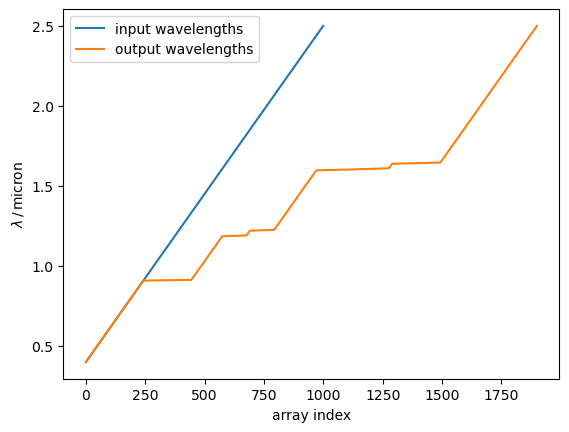

In [22]:
plt.plot(obs_wavelengths.to_value('micron'), label='input wavelengths')
plt.plot(disk_flux.waveset.to_value('micron'), label='output wavelengths')
plt.legend()
plt.xlabel('array index')
plt.ylabel(r'$\lambda \, / \, \mathrm{micron}$')

If we do want to use a uniform grid of wavelengths, this will need to be high enough resolution to properly resolve the emission lines. To see what happens if we don't do this, inspect the right panel of the figure below (which zooms in on the brightest emission line from the spectrum on the left). The flux in the emission lines is not conserved, because the lower-resolution spectrum is found with simple interpolation from the native resolution spectrum.

Text(0, 0.5, '$F_\\nu \\, / \\, \\mathrm{erg \\, s^{-1} \\, cm^{-2} \\, Hz^{-1}}$')

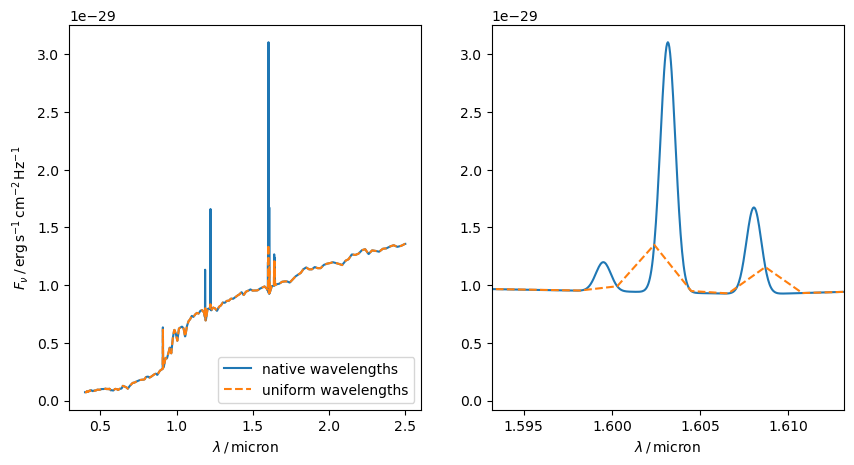

In [23]:
fig, axs = plt.subplots(1,2, figsize=(10,5))
for ax in axs:
    ax.plot(disk_flux.waveset.to_value('micron'), disk_flux(disk_flux.waveset, flux_unit='FNU'), label='native wavelengths')
    ax.plot(obs_wavelengths.to_value('micron'), disk_flux(obs_wavelengths, flux_unit='FNU'), label='uniform wavelengths',ls='--')
    ax.set_xlabel(r'$\lambda \, / \, \mathrm{micron}$')
peak_wav = (disk_flux.waveset[disk_flux(disk_flux.waveset, flux_unit='FNU').argmax()]).to_value('micron')
axs[1].set_xlim(peak_wav-0.01, peak_wav+0.01)
axs[0].legend()
axs[0].set_ylabel('' + r'$F_\nu \, / \, \mathrm{erg \, s^{-1} \, cm^{-2} \, Hz^{-1}}$')

If instead we interpolate onto a high resolution uniform grid of wavelengths then all is well.

Text(0, 0.5, '$F_\\nu \\, / \\, \\mathrm{erg \\, s^{-1} \\, cm^{-2} \\, Hz^{-1}}$')

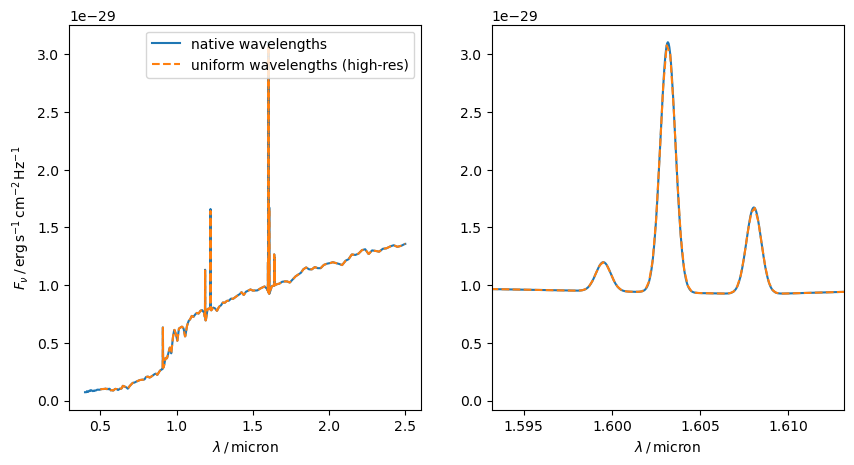

In [24]:
fig, axs = plt.subplots(1,2, figsize=(10,5))
high_res_wavelengths = np.linspace(0.5, 2.5, 10000)*u.micron
for ax in axs:
    ax.plot(disk_flux.waveset.to_value('micron'), disk_flux(disk_flux.waveset, flux_unit='FNU'), label='native wavelengths')
    ax.plot(high_res_wavelengths.to_value('micron'), disk_flux(high_res_wavelengths, flux_unit='FNU'), label='uniform wavelengths (high-res)',ls='--')
    ax.set_xlabel(r'$\lambda \, / \, \mathrm{micron}$')
peak_wav = (disk_flux.waveset[disk_flux(disk_flux.waveset, flux_unit='FNU').argmax()]).to_value('micron')
axs[1].set_xlim(peak_wav-0.01, peak_wav+0.01)
axs[0].legend()
axs[0].set_ylabel('' + r'$F_\nu \, / \, \mathrm{erg \, s^{-1} \, cm^{-2} \, Hz^{-1}}$')

Depending on how we use the Galacticus galaxies in the grism simulations, we may want to get spectra for each component individually, or just for the galaxy as a whole. The example below plots the spectra for each galactic component (`disk`, `spheroid` and `AGN`) separately, as well as their combination.  

(0.0, 3.432131377815723e-29)

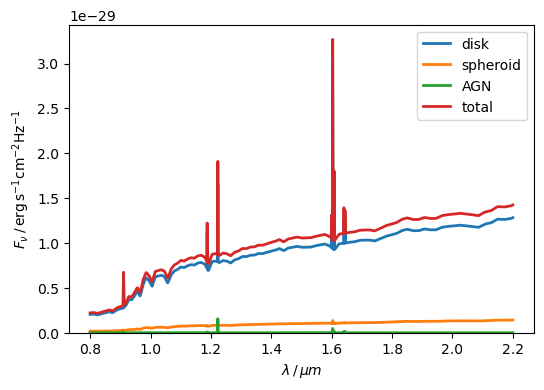

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

plotWavelengths = np.linspace(0.8,2.2,10000)*u.micron

spectra = []
for component in ['disk', 'spheroid', 'AGN']:
    component_flux = sedCalc.evaluate_component_spectrum(fname, galIndex, component=component, obs_wavelengths=obs_wavelengths)
    ax.plot(plotWavelengths, component_flux(plotWavelengths, flux_unit='FNU'), lw=2, label=component)
total_flux = sedCalc.evaluate_total_spectrum(fname, galIndex, obs_wavelengths=obs_wavelengths)
ax.plot(plotWavelengths, total_flux(plotWavelengths, flux_unit='FNU'), label='total', lw=2)
ax.set_xlabel(r'$\lambda \, / \, \mu m$')
ax.legend()
ax.set_ylabel(r'$F_\nu \, / \, \mathrm{erg \, s^{-1} cm^{-2} Hz^{-1}}$')
ax.set_ylim(ymin=0)

#### Emission line widths
One thing I haven't thought much about is the width of the emission lines. Currently the `sedCalc.evaluate_component_spectrum` and `sedCalc.evaluate_total_spectrum` are set up to accept a `lineFWHM` which is the observed-frame FWHM of every emission line (as a wavelength). If we want something different (same $\Delta \lambda / \lambda$ for each line, or a different $\Delta \lambda$ for every line, etc.) then this would be easy enough to do.

As an example of changing the `lineFWHM`, below we make the lines broader.

(0.0, 1.4948532554882318e-29)

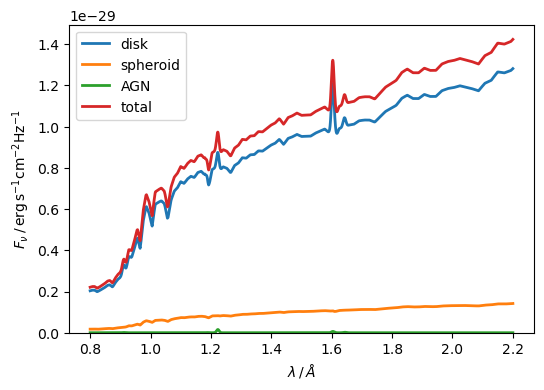

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))

plotWavelengths = np.linspace(0.8,2.2,10000)*u.micron
emissionLineWidth = 0.01*u.micron

spectra = []
for component in ['disk', 'spheroid', 'AGN']:
    component_flux = sedCalc.evaluate_component_spectrum(fname, galIndex, component=component, obs_wavelengths=obs_wavelengths, lineFWHM=emissionLineWidth)
    ax.plot(plotWavelengths, component_flux(plotWavelengths, flux_unit='FNU'), lw=2, label=component)
total_flux = sedCalc.evaluate_total_spectrum(fname, galIndex, obs_wavelengths=obs_wavelengths, lineFWHM=emissionLineWidth)
ax.plot(plotWavelengths, total_flux(plotWavelengths, flux_unit='FNU'), label='total', lw=2)
ax.set_xlabel(r'$\lambda \, / \, \AA$')
ax.legend()
ax.set_ylabel(r'$F_\nu \, / \, \mathrm{erg \, s^{-1} cm^{-2} Hz^{-1}}$')
ax.set_ylim(ymin=0)

#### Faster SEDs

The object returned by `sedCalc.evaluate_total_spectrum` is (by default) a `synphot` `SourceSpectrum` object. These are slightly slower to generate than raw numpy arryas, so (as an alternative) you can run `sedCalc.evaluate_total_spectrum` and `sedCalc.evaluate_component_spectrum` with `use_synphot=False`. What is returned is now a tuple (wavelengths, fnu), with both arrays having astropy units.

Below you can see a comparison of the spectrum of the different components of an example galaxy. 

In [29]:
sedCalc.evaluate_component_spectrum(fname, galIndex, component=component, obs_wavelengths=plotWavelengths, use_synphot=False)

/home/arobertson/.conda/envs/galacticus-dust/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0, 0.5, '$F_\\nu^\\mathrm{numpy} / F_\\nu^\\mathrm{synphot}$')

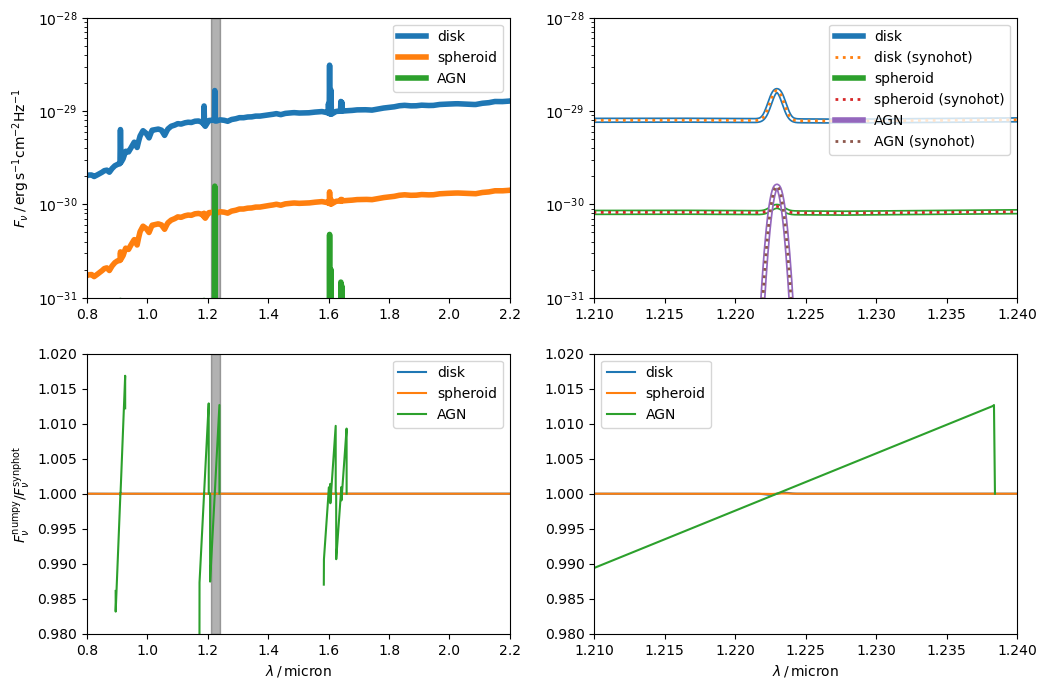

In [46]:
fig, axs = plt.subplots(nrows=2,ncols=2, figsize=(12, 8))

plotWavelengths = np.linspace(0.8,2.2,int(2e4))*u.micron
xlimZoom = [1.21, 1.24]

for component in ['disk', 'spheroid', 'AGN']:
    # use synphot
    component_flux = sedCalc.evaluate_component_spectrum(fname, galIndex, component=component, obs_wavelengths=plotWavelengths)
    # no synphot
    component_flux_noSynphot = sedCalc.evaluate_component_spectrum(fname, galIndex, component=component, obs_wavelengths=plotWavelengths, use_synphot=False)
    for ax in axs[0]:
        ax.plot(plotWavelengths, component_flux(plotWavelengths, flux_unit='FNU'), lw=4, label=component)
    #ax.plot(wav.to_value('micron'), fnu.to_value('erg / (s cm^2 Hz)'), ls='--', lw=2)
    for ax in axs[1]:
        ax.plot(plotWavelengths, component_flux_noSynphot(plotWavelengths, flux_unit='FNU')/component_flux(plotWavelengths, flux_unit='FNU'), label=component)
    axs[0,1].plot(plotWavelengths, component_flux_noSynphot(plotWavelengths, flux_unit='FNU'), ls='-', lw=1.5, c='w')
    axs[0,1].plot(plotWavelengths, component_flux_noSynphot(plotWavelengths, flux_unit='FNU'), ls=':', lw=2, label=f"{component} (synohot)")
axs[0,0].set_ylabel(r'$F_\nu \, / \, \mathrm{erg \, s^{-1} cm^{-2} Hz^{-1}}$')
for ax in axs[:,0]:
    ax.legend()
    ax.set_xlim(0.8,2.2)
    ax.axvspan(*xlimZoom, color='k', alpha=0.3)
for ax in axs[:,1]:
    ax.legend()
    ax.set_xlim(1.21,1.24)
for ax in axs[1]:
    ax.set_xlabel(r'$\lambda \, / \,$micron')
    ax.set_ylim(0.98,1.02)
for ax in axs[0]:
    ax.set_yscale('log')
    ax.set_ylim(1e-31,1e-28)
axs[1,0].set_ylabel(r'$F_\nu^\mathrm{numpy} / F_\nu^\mathrm{synphot}$')


#### Calculating observed magnitudes in photometric bands

Using `stpsf`, we can load Roman WFI filter transmission curves and calculate observed magnitudes from the galaxy spectra.

In [34]:
import stpsf

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf
/home/arobertson/.conda/envs/galacticus-dust/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's first have a quick look at the filter transmission curves

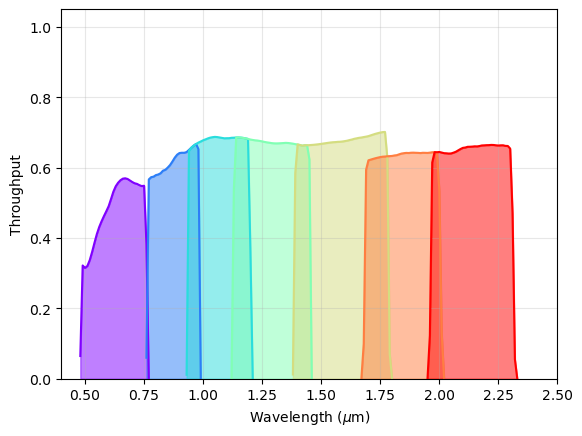

In [35]:
# Set up the Roman WFI object and make a list of the optical element names
roman = stpsf.WFI()
roman_filters = ["F062", "F087", "F106", "F129", "F158", "F184", "F213"]
 
# Set up wavelengths from 0.4 to 2.5 microns in increments of 0.01 microns.
waves = np.arange(0.4, 2.5, 0.01) * u.micron
 
# Set up figure
fig, ax = plt.subplots()
 
# For each optical element, plot the throughput in a different color
# and shade the area below the curve.
colors = plt.cm.rainbow(np.linspace(0, 1, len(roman_filters)))

for i, f in enumerate(roman_filters):
    band = roman._get_synphot_bandpass(f)
    clean = np.where(band(waves) > 0)

    ax.plot(waves[clean], band(waves[clean]), 
            color=colors[i])
    
    ax.fill_between(waves[clean].value, 
                    band(waves[clean]).value, 
                    alpha=0.5, 
                    color=colors[i])
 
# Set plot axis labels, ranges, and add grid lines
ax.set_xlabel(r'Wavelength ($\mu$m)')
ax.set_ylabel('Throughput')

ax.set_ylim(0, 1.05)
ax.set_xlim(0.4, 2.5)

ax.grid(':', alpha=0.3)

plt.show()

Using these filters, we can calculate magnitudes in multiple Roman bands:

In [36]:
# Get total galaxy spectrum (disk + spheroid)
total_flux = sedCalc.evaluate_total_spectrum(fname, galIndex, 
                                              obs_wavelengths=obs_wavelengths)

# Calculate magnitudes
for filter_name in roman_filters:
    bandpass = roman._get_synphot_bandpass(f'{filter_name}')
    obs = synphot.Observation(total_flux, bandpass)
    mag = obs.effstim(flux_unit=u.ABmag)
    print(f"{filter_name.upper():5s}: {mag:.2f}")

F062 : 26.18 mag(AB)
F087 : 25.18 mag(AB)
F106 : 24.29 mag(AB)
F129 : 23.99 mag(AB)
F158 : 23.80 mag(AB)
F184 : 23.67 mag(AB)
F213 : 23.55 mag(AB)


Let's overlay these photometric measurements on top of the corresponding spectrum

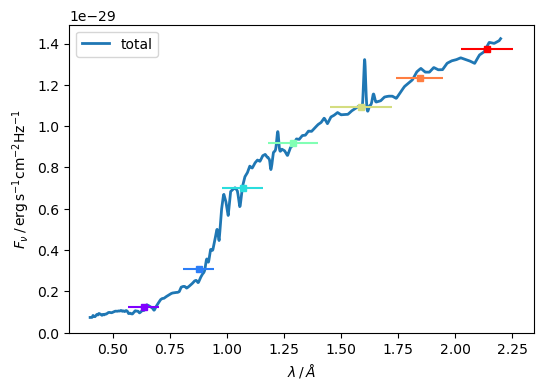

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))

plotWavelengths = np.linspace(0.4,2.2,10000)*u.micron
emissionLineWidth = 0.01*u.micron

total_flux = sedCalc.evaluate_total_spectrum(fname, galIndex, obs_wavelengths=obs_wavelengths, lineFWHM=emissionLineWidth)
ax.plot(plotWavelengths, total_flux(plotWavelengths, flux_unit='FNU'), label='total', lw=2)
ax.set_xlabel(r'$\lambda \, / \, \AA$')
ax.legend()
ax.set_ylabel(r'$F_\nu \, / \, \mathrm{erg \, s^{-1} cm^{-2} Hz^{-1}}$')
ax.set_ylim(ymin=0)

# Calculate magnitudes
magnitudes = {}
for i, filter_name in enumerate(roman_filters):
    bandpass = roman._get_synphot_bandpass(f'{filter_name}')
    obs = synphot.Observation(total_flux, bandpass)
    ax.errorbar(bandpass.avgwave().to_value(u.micron), obs.effstim(flux_unit=u.fnu), xerr=0.5*bandpass.equivwidth().to_value(u.micron), c=colors[i], marker='s', markersize=5)

#### Additional Galacticus properties

In [38]:
f = h5py.File(fname, 'r')

In addition to the galaxy SEDs, Galacticus also predicts the size and morphology of each galaxy. A Galacticus galaxy is composed of two seperate stellar components, a disk and a spheroid. The disks are assumed to have an exponential profile, while the spheroid is modelled as a Hernquist profile. The sizes of these components can be accessed with the following:

Get the exponential scale-length of the disk (note that these are physical, not comoving, sizes)

In [39]:
(f['/Lightcone/Output1/nodeData/diskRadius'][galIndex]*u.Mpc).to('kpc')

<Quantity 1.58582393 kpc>

We can verify that the disk scale length is in Mpc using the hdf5 metadata (`attrs`)

In [40]:
for key, value in f['/Lightcone/Output1/nodeData/diskRadius'].attrs.items():
    print(f"{key}: {value}")
print("1 Mpc is", (1*u.Mpc).to('m'))

comment: b'Radial scale length in the standard disk.'
unitsInSI: 3.08567758135e+22
1 Mpc is 3.085677581491367e+22 m


Similarly, we can find the size of the spheroid

In [41]:
(f['/Lightcone/Output1/nodeData/spheroidRadius'][galIndex]*u.Mpc).to('kpc')

<Quantity 0.08520107 kpc>

These sizes could (should?) be used within the grism simulations. In addition (and I don't know how important this is) one could imagine broadening lines based on the associated velocity of each component. For example, both disks and spheroids have a characteristic circular velocity.

In [42]:
print(f['/Lightcone/Output1/nodeData/diskVelocity'][galIndex]*u.km/u.s)

95.12942386587501 km / s


In [43]:
for key, value in f['/Lightcone/Output1/nodeData/diskVelocity'].attrs.items():
    print(f"{key}: {value}")

comment: b'Circular velocity of the standard disk at scale length.'
unitsInSI: 1000.0


In [44]:
print((f['/Lightcone/Output1/nodeData/spheroidVelocity'][galIndex]*u.km/u.s))

82.3356021767288 km / s


In [45]:
for key, value in f['/Lightcone/Output1/nodeData/spheroidVelocity'].attrs.items():
    print(f"{key}: {value}")

comment: b'Circular velocity at the scale length of the standard spheroid.'
unitsInSI: 1000.0


#### AGN spectra

Currently we are only outputting emission lines due to AGN, but Andrew Benson is looking in to additionally ouputting AGN continuum emission. I have no sense of how important AGN are for Roman's GRS, so maybe we don't want to include them at all, maybe we just want to include the emission lines, and maybe we want everything. Something to discuss in the future...